<a href="https://colab.research.google.com/github/prvallejoz/ejercicio3-mcib-b/blob/dev_prvallejo/TAREA_3_GRUPO_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# 1. IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style="whitegrid")


In [2]:
# 2. CARGA DEL DATASET

# Cargar los datos desde la ruta indicada
# Para ejecutar desde VSCODE asegúrate de que el archivo 'hotel_bookings.csv' esté en el mismo directorio que este notebook.
data = pd.read_csv('hotel_bookings.csv')

#Para ejecutar desde Colab, primero sube el archivo 'hotel_bookings.csv' a tu entorno de Colab "/content/" y luego usa la siguiente línea para cargarlo retirando el comentario:
#Recuerda comentar la línea anterior si usas esta opción para evitar errores de carga.

# data = pd.read_csv('/content/hotel_bookings.csv')

# Mostrar dimensiones y primeras 5 filas
print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# 3. LIMPIEZA DE DATOS

# Eliminar registros duplicados

print("Dimensiones iniciales:", data.shape)
print("\nTipos de datos:")
print(data.dtypes)

Dimensiones iniciales: (119390, 32)

Tipos de datos:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type           

In [4]:
print("\nPrimeras filas:")
display(data.head())


Primeras filas:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
print("\nValores nulos por columna:")
display(data.isnull().sum().sort_values(ascending=False))


Valores nulos por columna:


company                           112593
agent                              16340
country                              488
children                               4
arrival_date_month                     0
arrival_date_week_number               0
hotel                                  0
is_canceled                            0
stays_in_weekend_nights                0
arrival_date_day_of_month              0
adults                                 0
stays_in_week_nights                   0
babies                                 0
meal                                   0
lead_time                              0
arrival_date_year                      0
distribution_channel                   0
market_segment                         0
previous_bookings_not_canceled         0
is_repeated_guest                      0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
previous_cancellations                 0
deposit_type    

In [6]:
print("\nDuplicados exactos detectados:", data.duplicated().sum())


Duplicados exactos detectados: 31994


In [7]:
duplicados_antes = data.duplicated().sum()

data.drop_duplicates(inplace=True)

duplicados_despues = data.duplicated().sum()

print("Duplicados antes:", duplicados_antes)
print("Duplicados después:", duplicados_despues)
print("Nuevo shape:", data.shape)

Duplicados antes: 31994
Duplicados después: 0
Nuevo shape: (87396, 32)


In [8]:
# 4. ANALISÍS DE COLUMNAS

# % de nulos
null_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

diagnostico = pd.DataFrame({
    'tipo_dato': data.dtypes,
    'nulos': data.isnull().sum(),
    '%_nulos': round((data.isnull().sum()/len(data))*100,2),
    'valores_unicos': data.nunique()
})

display(diagnostico.sort_values('%_nulos', ascending=False))

,tipo_dato,nulos,%_nulos,valores_unicos
company,float64,82137,93.98,352
agent,float64,12193,13.95,333
country,str,452,0.52,177
hotel,str,0,0.00,2
arrival_date_month,str,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
lead_time,int64,0,0.00,479
is_canceled,int64,0,0.00,2
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35


In [9]:
#5. ELIMINAR COLUMNAS DE DATASET

columnas_a_borrar = ['company', 'agent', 'reservation_status', 'reservation_status_date']

data.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

print("Columnas eliminadas correctamente.")
print("Nuevo total columnas:", data.shape[1])

Columnas eliminadas correctamente.
Nuevo total columnas: 28


In [10]:
# 6 ANALIZAR NULOS DE COLUMNAS CHILDREN Y COUNTRY

cols_null = ['children', 'country']

for col in cols_null:
    if col in data.columns:
        print(f"{col} -> nulos antes:", data[col].isnull().sum())

children -> nulos antes: 4
country -> nulos antes: 452


In [11]:
# Rellenar valores faltantes
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['country'] = data['country'].fillna(data['country'].mode()[0])

In [12]:
# 7. VALIDACIÓN GENERAL DE VALORES NULOS

nulos = data.isnull().sum()
nulos_restantes = nulos[nulos > 0]

print("Columnas con nulos restantes:")
display(nulos_restantes.sort_values(ascending=False))

print("Total nulos restantes:", nulos_restantes.sum())

Columnas con nulos restantes:


Series([], dtype: int64)

Total nulos restantes: 0


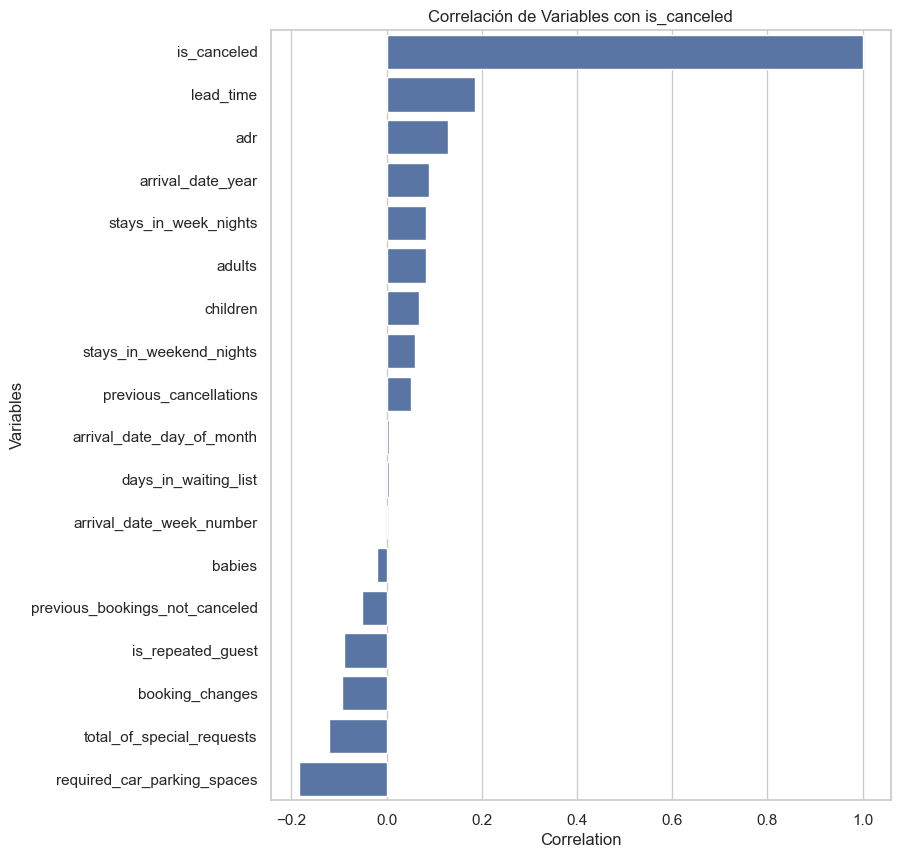

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64


In [13]:

# 8. CORRELACIÓN CON LA VARIABLE TARGET
# Identificar variables mas relacionada con la cancelacion

corr_target = data.select_dtypes(include=np.number).corr()['is_canceled'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlación de Variables con is_canceled")
plt.xlabel("Correlation")
plt.ylabel("Variables")
plt.show()

print(corr_target)

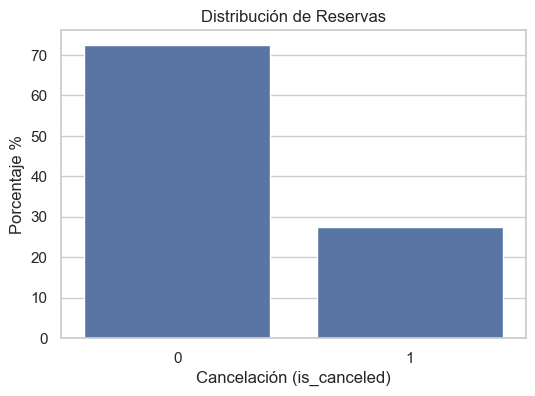

is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64


In [43]:
# 9. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# Revisar balance de clases
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=data, stat='percent')
plt.title("Distribución de Reservas")
plt.xlabel("Cancelación (is_canceled)")
plt.ylabel("Porcentaje %")
plt.show()

print(data['is_canceled'].value_counts(normalize=True))

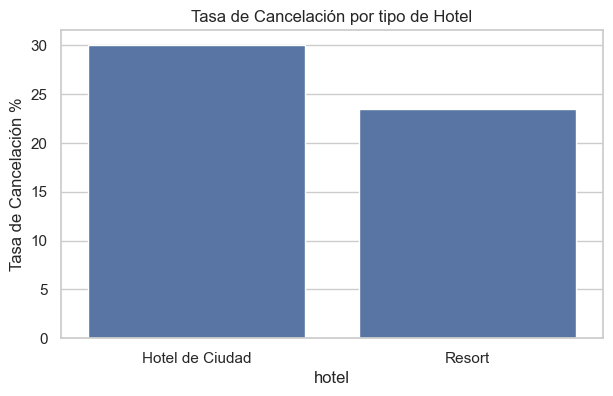

In [49]:
# 10. CANCELACIÓN POR TIPO DE HOTEL

cancel_hotel = data.groupby('hotel')['is_canceled'].mean()*100
cancel_hotel = cancel_hotel.sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=cancel_hotel.index, y=cancel_hotel.values)
plt.xticks(ticks=[0, 1], labels=['Hotel de Ciudad', 'Resort'])
plt.title("Tasa de Cancelación por tipo de Hotel")
plt.ylabel("Tasa de Cancelación %")
plt.show()

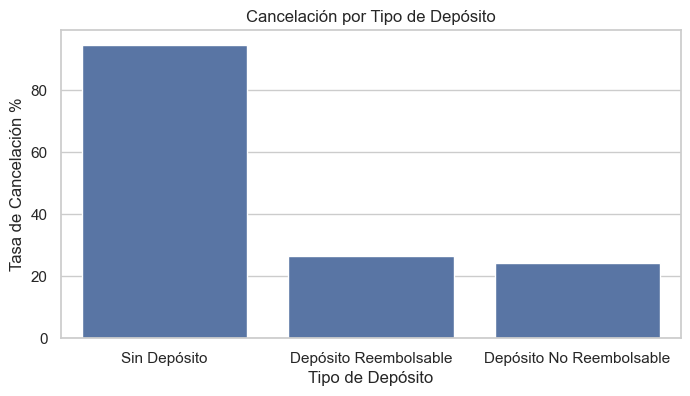

In [56]:
# 11. CANCELACIÓN POR TIPO DE DEPÓSITO

cancel_dep = data.groupby('deposit_type')['is_canceled'].mean()*100
cancel_dep = cancel_dep.sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=cancel_dep.index, y=cancel_dep.values)
plt.xticks(ticks=[0, 1, 2], labels=['Sin Depósito', 'Depósito Reembolsable', 'Depósito No Reembolsable'])
plt.title("Cancelación por Tipo de Depósito")
plt.xticks(rotation=0)
plt.xlabel("Tipo de Depósito")
plt.ylabel("Tasa de Cancelación %")
plt.show()

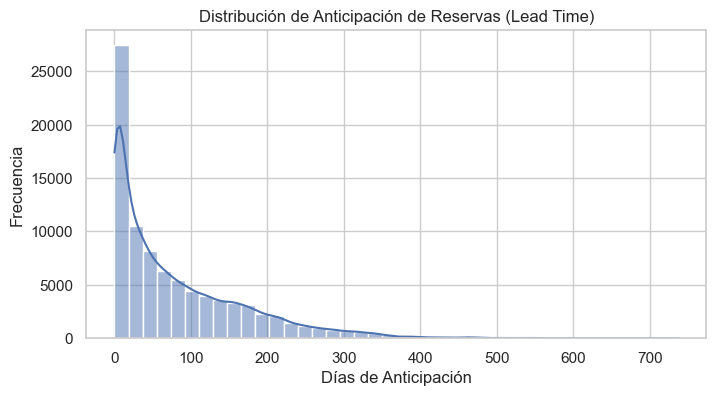

In [58]:
# 12. DISTRIBUCIÓN DE ANTICIPACIÓN DE RESERVAS (LEAD TIME)
# Ver comportamiento reservas anticipadas
plt.figure(figsize=(8,4))
sns.histplot(data['lead_time'], bins=40, kde=True)
plt.title("Distribución de Anticipación de Reservas (Lead Time)")
plt.xlabel("Días de Anticipación")
plt.ylabel("Frecuencia")
plt.show()

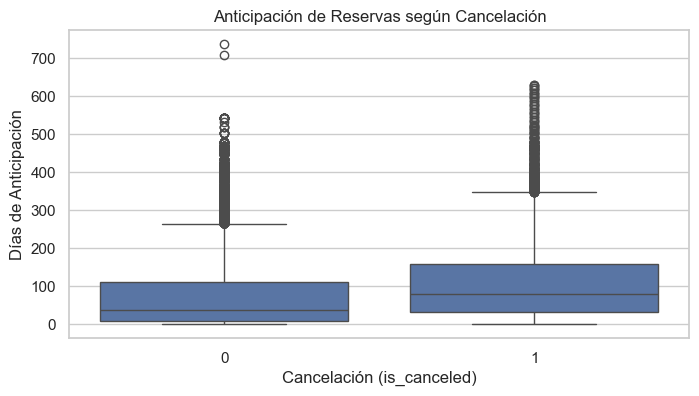

In [60]:
# 13. COMPARACIÓN DE ANTICIPACIÓN DE RESERVAS ENTRE CANCELADAS Y NO CANCELADAS

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='lead_time', data=data)
plt.title("Anticipación de Reservas según Cancelación")
plt.xlabel("Cancelación (is_canceled)")
plt.ylabel("Días de Anticipación")
plt.show()

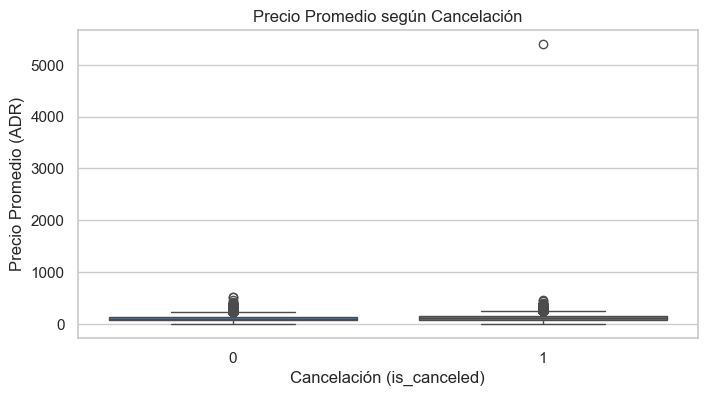

In [62]:
# 14. PRECIO PROMEDIO vs CANCELACIÓN
# Revisar si precio influye

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='adr', data=data)
plt.title("Precio Promedio según Cancelación")
plt.xlabel("Cancelación (is_canceled)")
plt.ylabel("Precio Promedio (ADR)")
plt.show()

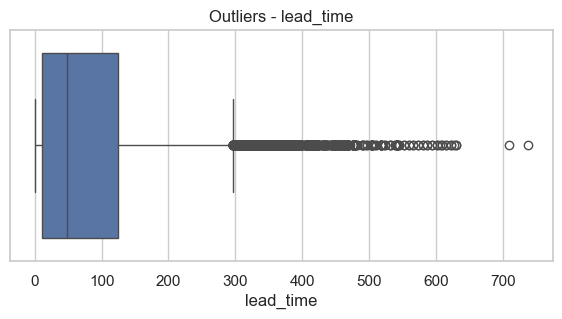

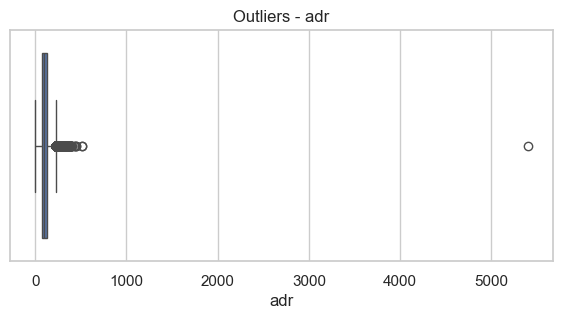

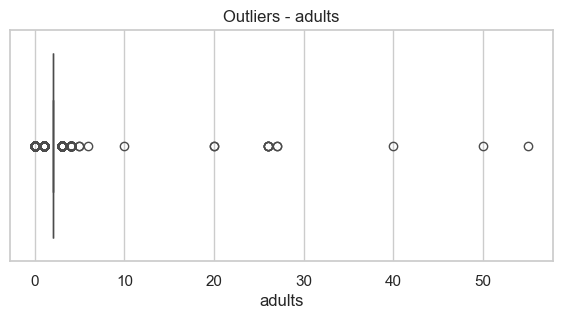

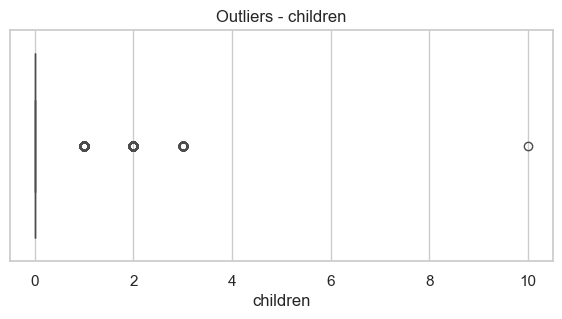

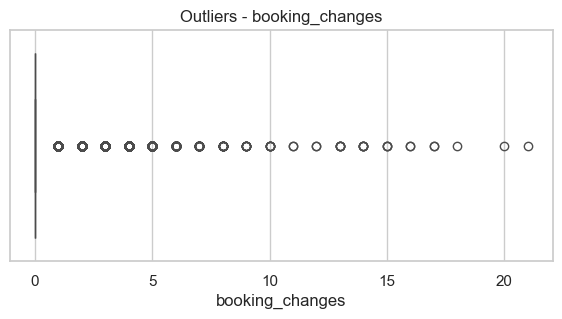

In [20]:
# 15. OUTLIERS NUMÉRICOS
# Detectar valores extremos

num_cols = ['lead_time','adr','adults','children','booking_changes']

for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=data[col])
    plt.title(f"Outliers - {col}")
    plt.show()

In [ ]:
# 16. Crear nuevas variables útiles

data['total_guests'] = data['adults'] + data['children'] + data['babies']
data['total_nights'] = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)

print(data[['total_guests','total_nights','is_family']].head())

   total_guests  total_nights  is_family
0           2.0             0          0
1           2.0             0          0
2           1.0             1          0
3           1.0             1          0
4           2.0             2          0


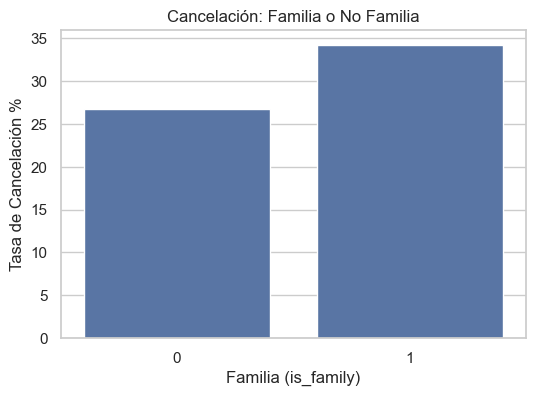

In [65]:
# 17. CANCELACIÓN POR RESERVAS FAMILIARES VS NO FAMILIARES

family_cancel = data.groupby('is_family')['is_canceled'].mean()*100

plt.figure(figsize=(6,4))
sns.barplot(x=family_cancel.index, y=family_cancel.values)
plt.title("Cancelación: Familia o No Familia")
plt.xlabel("Familia (is_family)")
plt.ylabel("Tasa de Cancelación %")
plt.show()

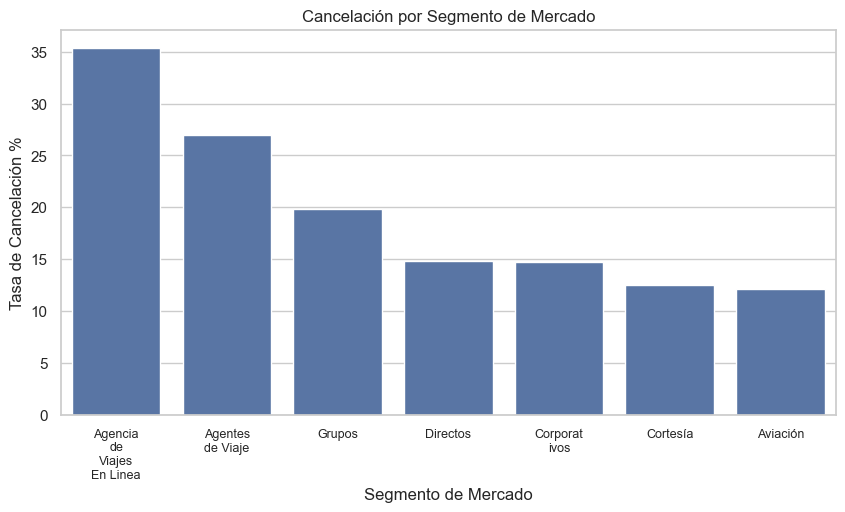

In [79]:

# 18. ANALIZAR CANCELACIÓN POR SEGMENTO DE MERCADO

import textwrap


seg = data[data['market_segment'] != 'Undefined'].groupby('market_segment')['is_canceled'].mean()*100
seg = seg.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=seg.index, y=seg.values)
plt.xticks(rotation=0, ha='center')
plt.title("Cancelación por Segmento de Mercado")
plt.ylabel("Tasa de Cancelación %")
plt.xlabel("Segmento de Mercado")
labels = ['Agencia de Viajes En Linea', 'Agentes de Viaje', 'Grupos', 'Directos', 'Corporativos', 'Cortesía', 'Aviación']
labels_wrapped = [textwrap.fill(label, width=8) for label in labels]
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=labels_wrapped, fontsize=9)
plt.show()

In [24]:
# 19. INSIGHTS

print("Promedio cancelación:", round(data['is_canceled'].mean(),3))
print("Lead time promedio cancelados:",
      round(data[data['is_canceled']==1]['lead_time'].mean(),2))
print("Lead time promedio no cancelados:",
      round(data[data['is_canceled']==0]['lead_time'].mean(),2))

Promedio cancelación: 0.275
Lead time promedio cancelados: 105.72
Lead time promedio no cancelados: 70.1


In [25]:
# 20. MATRIZ DE CORRELACIÓN

matriz_corr = data.select_dtypes(include=['float64', 'int64']).corr()
matriz_corr

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,is_family
is_canceled,1.000000,0.184806,0.088030,0.001443,0.005328,0.060191,0.082928,0.081816,0.067369,-0.020543,...,0.051468,-0.052154,-0.093644,0.004464,0.127986,-0.184206,-0.120545,0.100257,0.084102,0.051649
lead_time,0.184806,1.000000,0.139135,0.101150,0.009866,0.235145,0.310129,0.140493,0.028650,-0.003614,...,0.005375,-0.078931,0.077028,0.132152,0.023564,-0.086541,0.034240,0.126736,0.318272,0.032004
arrival_date_year,0.088030,0.139135,1.000000,-0.514228,-0.010023,0.005144,0.003645,0.038619,0.041158,-0.023334,...,-0.054212,0.027256,0.008604,-0.027939,0.176088,-0.039807,0.064268,0.050744,0.004630,0.035797
arrival_date_week_number,0.001443,0.101150,-0.514228,1.000000,0.093594,0.026868,0.027801,0.024362,0.013450,0.014260,...,0.007199,-0.020819,0.011902,0.013843,0.098279,0.008946,0.046599,0.028973,0.030693,0.020103
arrival_date_day_of_month,0.005328,0.009866,-0.010023,0.093594,1.000000,-0.017803,-0.028190,-0.001125,0.015821,-0.000393,...,-0.008538,0.000152,0.006307,0.006588,0.022591,0.009167,-0.001651,0.008136,-0.027597,0.016493
stays_in_weekend_nights,0.060191,0.235145,0.005144,0.026868,-0.017803,1.000000,0.555552,0.088284,0.028561,0.013668,...,-0.020636,-0.056653,0.050316,-0.031680,0.038972,-0.042920,0.032396,0.087979,0.786262,0.033072
stays_in_week_nights,0.082928,0.310129,0.003645,0.027801,-0.028190,0.555552,1.000000,0.095577,0.030479,0.016009,...,-0.018781,-0.058503,0.085044,0.001905,0.053298,-0.044303,0.037823,0.095166,0.950577,0.034986
adults,0.081816,0.140493,0.038619,0.024362,-0.001125,0.088284,0.095577,1.000000,0.023712,0.016640,...,-0.042097,-0.120914,-0.048061,-0.015740,0.248999,0.007802,0.112772,0.804715,0.103992,0.047511
children,0.067369,0.028650,0.041158,0.013450,0.015821,0.028561,0.030479,0.023712,1.000000,0.017423,...,-0.019208,-0.029423,0.031313,-0.020419,0.326293,0.036332,0.044596,0.595109,0.033315,0.891861
babies,-0.020543,-0.003614,-0.023334,0.014260,-0.000393,0.013668,0.016009,0.016640,0.017423,1.000000,...,-0.005395,-0.009193,0.081035,-0.006840,0.023446,0.030885,0.094820,0.166135,0.017000,0.279451


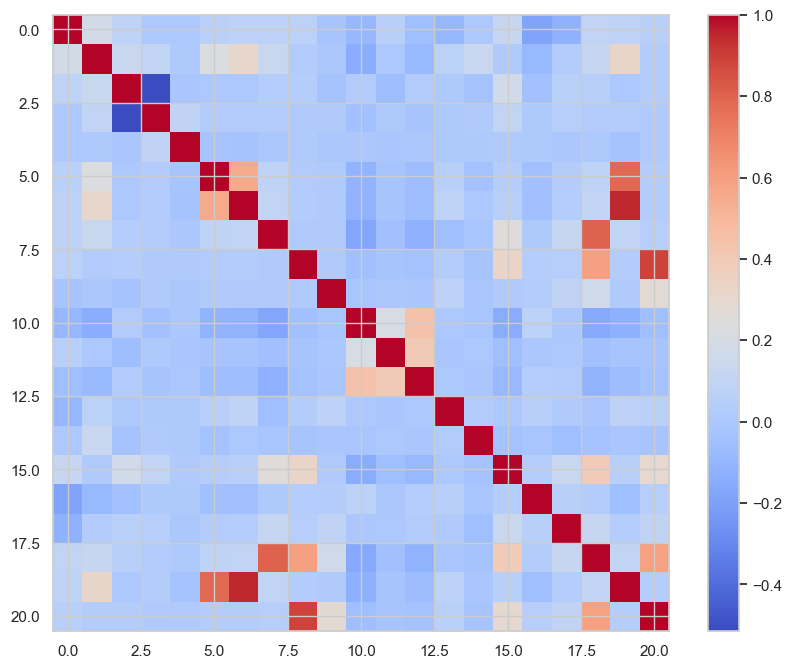

In [26]:
# 21. HEATMAP DE CORRELACIÓN

plt.figure(figsize=(10, 8))
plt.imshow(matriz_corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

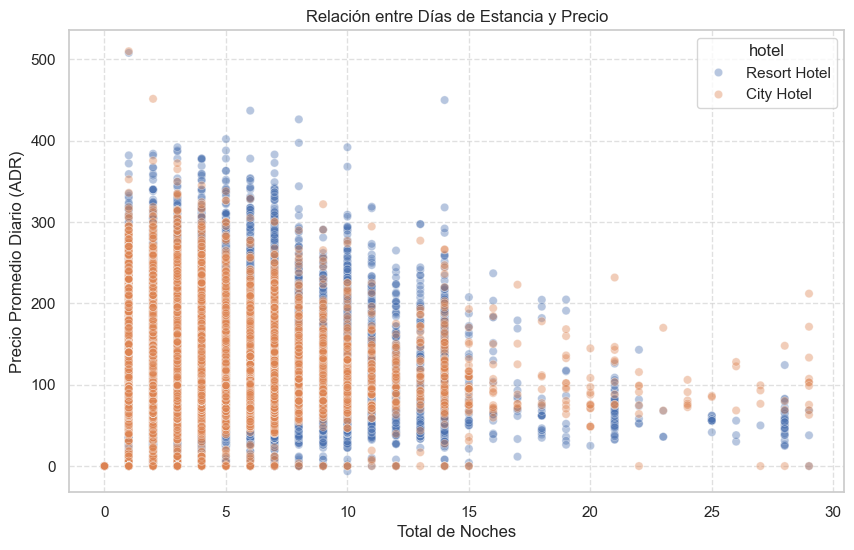

In [27]:
# 22. SCATTER PLOT DÍAS DE ESTANCIA VS PRECIO PROMEDIO

data['total_nights'] = data['stays_in_weekend_nights'] + data['stays_in_week_nights']

df_plot = data[(data['adr'] < 1000) & (data['total_nights'] < 30)]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='total_nights', y='adr', hue='hotel', alpha=0.4)
plt.title('Relación entre Días de Estancia y Precio')
plt.xlabel('Total de Noches')
plt.ylabel('Precio Promedio Diario (ADR)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

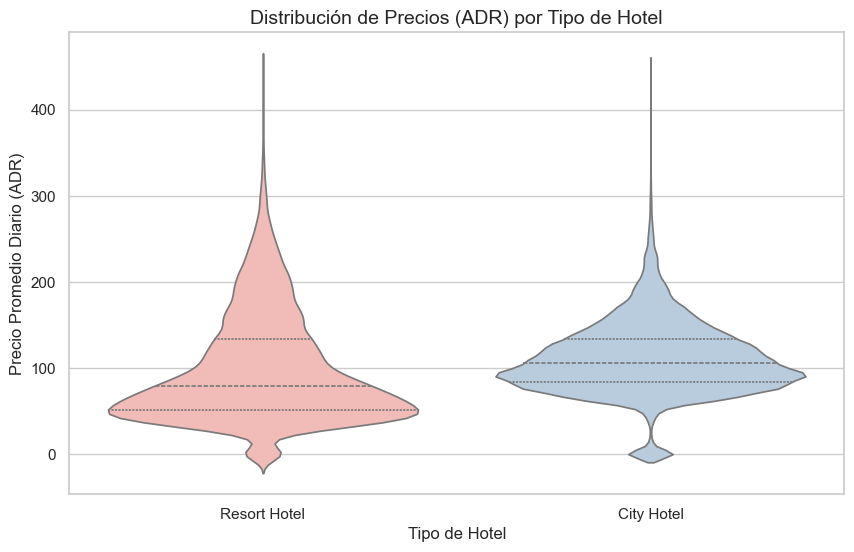

In [28]:
# 23. VIOLIN PLOT DE PRECIO PROMEDIO POR TIPO DE HOTEL

df_filtered = data[data['adr'] < 500]

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_filtered, x='hotel', y='adr', palette='Pastel1', inner='quartile', hue='hotel')
plt.title('Distribución de Precios (ADR) por Tipo de Hotel', fontsize=14)
plt.xlabel('Tipo de Hotel', fontsize=12)
plt.ylabel('Precio Promedio Diario (ADR)', fontsize=12)

plt.show()

Las reservas que terminan cancelándose fueron hechas, en promedio, con más anticipación que las reservas no canceladas.

Esto sugiere que mientras más tiempo pasa entre la reserva y la fecha de llegada, mayor puede ser la probabilidad de cancelación, posiblemente porque los clientes cambian planes, encuentran mejores opciones o modifican su viaje.

La variable lead_time parece ser un factor importante para predecir cancelaciones, por lo que se espera que tenga peso relevante en los modelos de Machine Learning.

In [29]:
# ==========================================
# BLOQUE 1. DEFINIR X e y
# Objetivo: Preparación para Machine Learning
# ==========================================

# X: variables explicativas (todo excepto is_canceled).
# y: variable objetivo (0=no canceló, 1=canceló).

X = data.drop(columns='is_canceled')
y = data['is_canceled']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87396, 30)
y shape: (87396,)


In [30]:
# ==========================================
# BLOQUE 2. IDENTIFICAR VARIABLES
# ==========================================

# Separamos columnas en:

# Categóricas: texto/categorías (hotel, meal, etc.).
# Numéricas: cantidades (lead_time, adr, etc.).

cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

print("Categorical:", len(cat_cols))
print(cat_cols)

print("Numerical:", len(num_cols))
print(num_cols[:20])

Categorical: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Numerical: 20
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'is_family']


In [31]:
# ==========================================
# BLOQUE 3. TRAIN TEST SPLIT
# ==========================================

# Reservamos datos para evaluar el modelo con información no vista.

# Train (80%): para aprender patrones.
# Test (20%): para medir rendimiento real.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(69916, 30) (17480, 30)


In [32]:
# ==========================================
# BLOQUE 4. PREPROCESSING PIPELINE
# ==========================================

# Transformaciones automáticas antes del modelo:

# StandardScaler: normaliza variables numéricas.
# OneHotEncoder: convierte categorías en columnas binarias.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [33]:
# ==========================================
# BLOQUE 5. MODELO BASE
# ==========================================

# En esta sección entrenamos el modelo base: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

prep → prepara los datos antes del modelo:
Escala variables numéricas con StandardScaler
Convierte variables categóricas en formato numérico con OneHotEncoder.

model → aplica LogisticRegression, que calcula la probabilidad de que una reserva sea cancelada.

El modelo de Logistic Regression fue utilizada como modelo base para establecer una referencia inicial. El entrenamiento se completó correctamente y el modelo quedó listo para evaluar su capacidad predictiva sobre nuevas reservas.

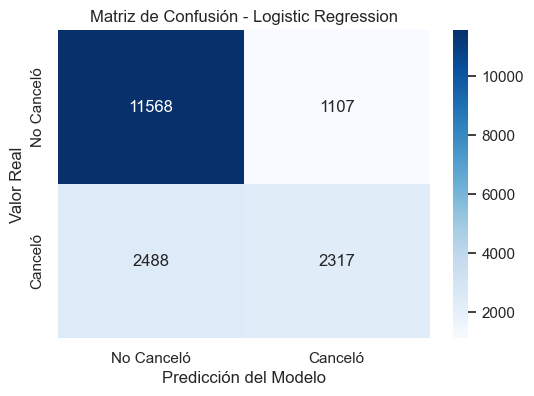

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480



In [34]:
# ==========================================
# BLOQUE 6. EVALUACIÓN LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones
pred_lr = lr_model.predict(X_test)

# Matriz de confusión numérica
cm = confusion_matrix(y_test, pred_lr)

# Visualización
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Canceló', 'Canceló'],
    yticklabels=['No Canceló', 'Canceló']
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, pred_lr))

El modelo identifica muy bien las reservas normales, pero pierde bastantes cancelaciones reales (2487 casos).

Accuracy = 0.79 (El modelo acierta el 79% de todas las predicciones.)

Precision clase 1 = 0.68 (Cuando el modelo predice cancelación, 68% de las veces tiene razón.)

Recall clase 1 = 0.48 (De todas las reservas que sí fueron canceladas, el modelo solo detecta 48%.)

F1-score clase 1 = 0.56 (Balance moderado entre precisión y recall.)

La Regresión Logística logró una precisión general aceptable (79%), pero su capacidad para detectar cancelaciones reales fue limitada, con un recall de 48%. Esto indica que funciona como modelo base, aunque sería recomendable probar modelos más avanzados para mejorar la detección de reservas canceladas.

In [35]:
# ==========================================
# BLOQUE 7. RANDOM FOREST
# ==========================================

# Es un modelo basado en muchos árboles de decisión trabajando en conjunto.
# En lugar de depender de un solo árbol, crea varios árboles y cada uno emite una
# predicción. Luego el modelo decide por votación mayoritaria.

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


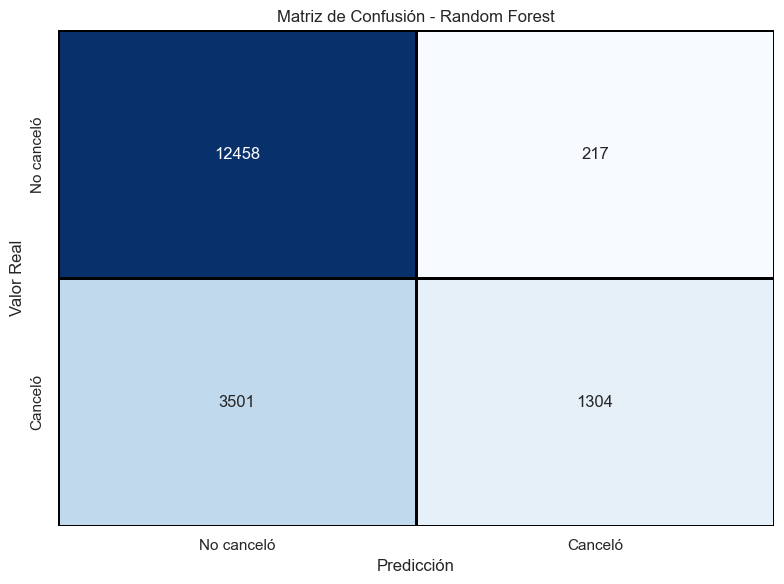

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.78      0.98      0.87     12675
           1       0.86      0.27      0.41      4805

    accuracy                           0.79     17480
   macro avg       0.82      0.63      0.64     17480
weighted avg       0.80      0.79      0.74     17480



In [36]:
# ==========================================
# BLOQUE 8. EVALUACIÓN RANDOM FOREST
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones
pred_rf = rf_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, pred_rf)

# Visualización
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black',
    xticklabels=['No canceló', 'Canceló'],
    yticklabels=['No canceló', 'Canceló']
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, pred_rf))

El modelo identifica muy bien las reservas normales, pero pierde una gran cantidad de cancelaciones reales (3501 casos).

Accuracy = 0.79 (El modelo acierta el 79% de todas las predicciones.)

Precision clase 1 = 0.86 (Cuando el modelo predice cancelación, 86% de las veces tiene razón.)

Recall clase 1 = 0.27 (De todas las reservas que sí fueron canceladas, el modelo solo detecta 27%.)

F1-score clase 1 = 0.41 (Balance bajo entre precisión y recall.)

El modelo Random Forest logró una precisión general aceptable (79%) y una alta precisión al predecir cancelaciones, pero su capacidad para detectar cancelaciones reales fue muy baja, con un recall de solo 27%. Esto indica que el modelo es demasiado conservador al identificar cancelaciones y, en este caso, tuvo un desempeño inferior a la Regresión Logística para el objetivo principal del proyecto.

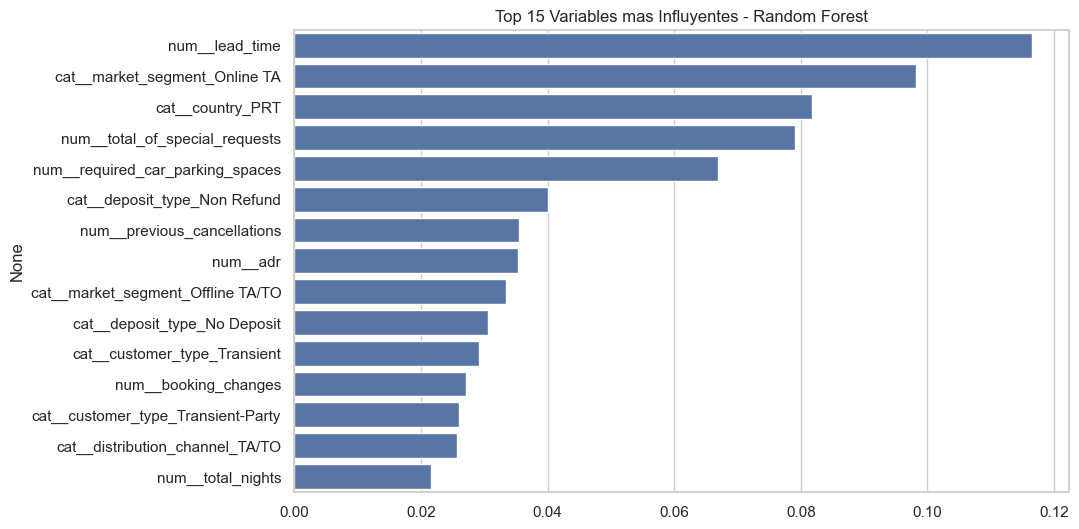

In [37]:
# Extraer modelo interno
rf_final = rf_model.named_steps['model']

# nombres columnas transformadas
feature_names = rf_model.named_steps['prep'].get_feature_names_out()

importances = pd.Series(
    rf_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Variables mas Influyentes - Random Forest")
plt.show()

El análisis de importancia de variables mostró que lead_time fue la característica más influyente en la predicción de cancelaciones, indicando que las reservas realizadas con mucha anticipación tienen mayor riesgo de cancelarse.

También destacaron variables como market_segment_Online TA, deposit_type, adr y previous_cancellations, lo que confirma que el canal de reserva, las políticas de pago, el precio y el historial del cliente son factores relevantes.

Estos resultados coinciden con el análisis exploratorio previo y aportan valor de negocio, ya que permiten enfocar estrategias preventivas en reservas de mayor riesgo.